### Default Set Transformer (Simplified Version)

Global max skills: 93

=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.832962  0.801555    0.147255  0.161799   0.109856  0.121892
1     2  0.809660  0.782614    0.157388  0.168484   0.119618  0.127094
2     3  0.809127  0.784551    0.157273  0.169162   0.119177  0.127274
3     4  0.839035  0.776630    0.145658  0.166403   0.108883  0.124059
4     5  0.832549  0.810146    0.147453  0.158200   0.111040  0.118261

SET TRANSFORMER (DEFAULT) - 5-FOLD CV (LOG SCALE)
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8247         0.7911         0.0336
RMSE               0.1510         0.1648               
MAE                0.1137         0.1237               

SET TRANSFORMER (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)
Metric              Train           Test
----------------------------------------------------------------------
R² 

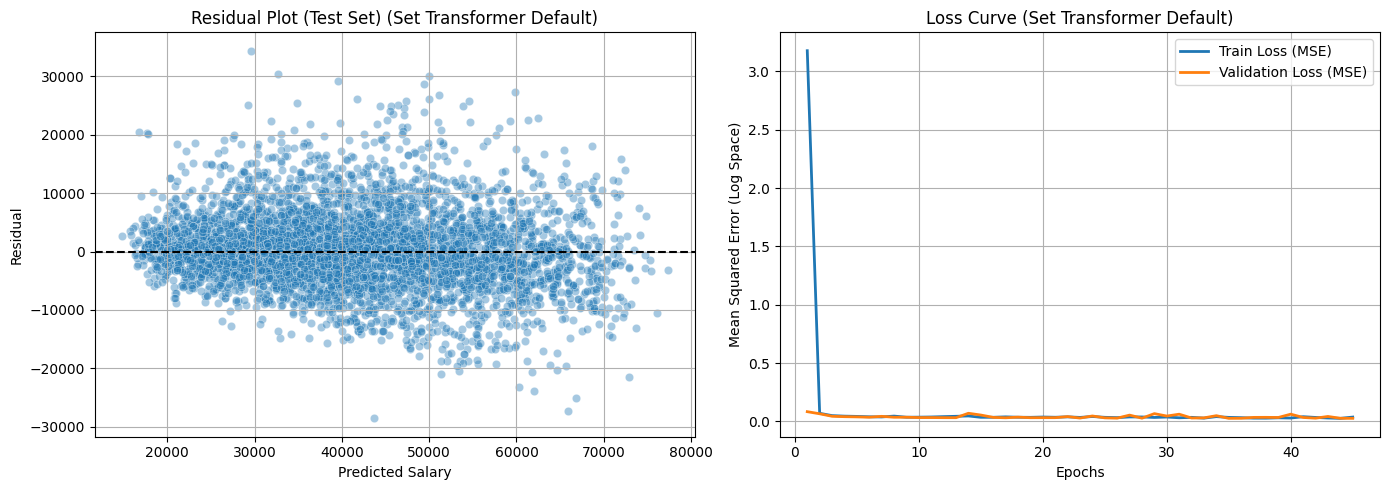

In [ ]:
import random
import warnings
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pickle
import copy
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, learning_curve
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")

# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LOAD DATA
df = pd.read_csv("../Unified_Resume_Salary_Dataset.csv")

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"].values

X_train_text = X_text.iloc[train_idx]
X_test_text = X_text.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]


vectorizer = CountVectorizer(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*'
)

X_train_count = vectorizer.fit_transform(X_train_text)
X_test_count = vectorizer.transform(X_test_text)


# LOAD ONTOLOGY EMBEDDINGS
emb_path = "../ontology_embeddings.npy"
ontology_embs = torch.tensor(np.load(emb_path)).to(device)

# Compute once from the full dataset, pass it in explicitly
global_max_skills = int(np.diff(
    vectorizer.transform(X_text).tocsr().indptr
).max())
print(f"Global max skills: {global_max_skills}")

def create_set_embeddings(X_count_matrix, embs_tensor, max_skills): 
    X_count_matrix = X_count_matrix.tocsr()
    embs = embs_tensor.cpu().numpy()
    n, d = X_count_matrix.shape[0], embs.shape[1]
    X_set = np.zeros((n, max_skills, d), dtype=np.float32)

    for i in range(n):
        start = X_count_matrix.indptr[i]
        end   = X_count_matrix.indptr[i + 1]
        idx   = X_count_matrix.indices[start:end][:max_skills] 
        if len(idx) > 0:
            X_set[i, :len(idx)] = embs[idx]
    return X_set

# Both use the same max_skills
X_train_set = create_set_embeddings(X_train_count, ontology_embs, global_max_skills)
X_test_set  = create_set_embeddings(X_test_count,  ontology_embs, global_max_skills)


# MODEL
class ISAB(nn.Module):
    def __init__(self, dim, heads, num_inducing=32):
        super().__init__()
        self.inducing = nn.Parameter(torch.randn(1, num_inducing, dim))
        self.mha1 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mha2 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)

    def forward(self, x):
        H, _ = self.mha1(self.inducing.repeat(x.size(0),1,1), x, x)
        H = self.ln1(H)
        out, _ = self.mha2(x, H, H)
        out = self.ln2(out)
        return x + out


class PMA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.seed = nn.Parameter(torch.randn(1, 1, dim))
        self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)

    def forward(self, x):
        out, _ = self.mha(self.seed.repeat(x.size(0),1,1), x, x)
        return out.mean(dim=1)


class TrueSetTransformer(BaseEstimator, RegressorMixin):
    def __init__(self, input_dim=768, hidden_dim=128, heads=4, num_inducing=32,
                 epochs=50, batch_size=128, lr=1.5e-3, patience=10):
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.heads = heads
        self.num_inducing = num_inducing
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.device = device

    def fit(self, X, y, eval_set=None):
        self.model = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            ISAB(self.hidden_dim, self.heads, num_inducing=self.num_inducing),
            ISAB(self.hidden_dim, self.heads, num_inducing=self.num_inducing),
            PMA(self.hidden_dim, self.heads),
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(self.device)

        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()

           
        X_t = torch.as_tensor(X, dtype=torch.float32, device=self.device)
        y_t = torch.as_tensor(y, dtype=torch.float32, device=self.device).view(-1, 1)

        if eval_set:
            X_val_t = torch.as_tensor(eval_set[0], dtype=torch.float32, device=self.device)
            y_val_t = torch.as_tensor(eval_set[1], dtype=torch.float32, device=self.device).view(-1, 1)

        best_loss = float("inf")
        best_state = copy.deepcopy(self.model.state_dict())
        patience_counter = 0
        n_samples = X_t.size(0)
        self.history = {"train_loss": [], "val_loss": []}

        for epoch in range(self.epochs):
            self.model.train()
            
            perm = torch.randperm(n_samples, device=self.device)
            epoch_train_loss = 0.0
            
            for i in range(0, n_samples, self.batch_size):
                idx = perm[i:i+self.batch_size]
                xb, yb = X_t[idx], y_t[idx]
                
                opt.zero_grad()
                pred = self.model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()
                
                epoch_train_loss += loss.item() * xb.size(0)
                
            epoch_train_loss /= n_samples   

                
            if eval_set:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    # Chunked eval to prevent VRAM spikes
                    for i in range(0, X_val_t.size(0), self.batch_size):
                        xb_v = X_val_t[i:i+self.batch_size]
                        yb_v = y_val_t[i:i+self.batch_size]
                        val_loss += loss_fn(self.model(xb_v), yb_v).item() * xb_v.size(0)
                current_loss = val_loss / X_val_t.size(0)
            else:
                current_loss = epoch_train_loss  

            self.history["train_loss"].append(epoch_train_loss)
            if eval_set:
                self.history["val_loss"].append(current_loss)
                
            # EARLY STOPPING LOGIC
            if current_loss < best_loss:
                best_loss = current_loss
                best_state = copy.deepcopy(self.model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= self.patience:
                break

        # Load best weights
        self.model.load_state_dict(best_state)
        
        # Flush Tensors
        del X_t, y_t
        if eval_set:
            del X_val_t, y_val_t
        torch.cuda.empty_cache()

        return self

    def predict(self, X):
        self.model.eval()
        X_t = torch.as_tensor(X, dtype=torch.float32, device=self.device)
        preds = []
        
        with torch.no_grad():
            for i in range(0, X_t.size(0), self.batch_size):
                xb = X_t[i:i+self.batch_size]
                preds.append(self.model(xb).cpu().numpy())
                
        # OOM PREVENTION
        del X_t
        torch.cuda.empty_cache()
        
        return np.vstack(preds).flatten()


# 5-FOLD CV
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

train_r2_scores, val_r2_scores = [], []
train_rmse_scores, val_rmse_scores = [], []
train_mae_scores, val_mae_scores = [], []

# Store per-fold 
fold_train_r2, fold_val_r2 = [], []
fold_train_rmse, fold_val_rmse = [], []
fold_train_mae, fold_val_mae = [], []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_set)):

    X_tr, X_va = X_train_set[tr_idx], X_train_set[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    model = TrueSetTransformer(input_dim=X_train_set.shape[2])
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

    tr_pred = model.predict(X_tr)
    va_pred = model.predict(X_va)

    # Compute metrics
    tr_r2 = r2_score(y_tr, tr_pred)
    va_r2 = r2_score(y_va, va_pred)

    tr_rmse = np.sqrt(mean_squared_error(y_tr, tr_pred))
    va_rmse = np.sqrt(mean_squared_error(y_va, va_pred))

    tr_mae = mean_absolute_error(y_tr, tr_pred)
    va_mae = mean_absolute_error(y_va, va_pred)

    # Store for averages
    train_r2_scores.append(tr_r2)
    val_r2_scores.append(va_r2)

    train_rmse_scores.append(tr_rmse)
    val_rmse_scores.append(va_rmse)

    train_mae_scores.append(tr_mae)
    val_mae_scores.append(va_mae)

    # Store per-fold table
    fold_train_r2.append(tr_r2)
    fold_val_r2.append(va_r2)

    fold_train_rmse.append(tr_rmse)
    fold_val_rmse.append(va_rmse)

    fold_train_mae.append(tr_mae)
    fold_val_mae.append(va_mae)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, kf.get_n_splits() + 1),

    "Train_R2": fold_train_r2,
    "Val_R2": fold_val_r2,

    "Train_RMSE": fold_train_rmse,
    "Val_RMSE": fold_val_rmse,

    "Train_MAE": fold_train_mae,
    "Val_MAE": fold_val_mae
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)


# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(train_r2_scores)
cv_val_r2   = np.mean(val_r2_scores)

cv_train_rmse = np.mean(train_rmse_scores)
cv_val_rmse   = np.mean(val_rmse_scores)

cv_train_mae = np.mean(train_mae_scores)
cv_val_mae   = np.mean(val_mae_scores)

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'SET TRANSFORMER (DEFAULT) - 5-FOLD CV (LOG SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
final_model = TrueSetTransformer(input_dim=X_train_set.shape[2])

# Split a small validation portion just for early stopping
X_final_tr, X_final_val, y_final_tr, y_final_val = train_test_split(
    X_train_set, y_train, test_size=0.1, random_state=seed
)

final_model.fit(X_final_tr, y_final_tr, eval_set=(X_final_val, y_final_val))

# Predictions (LOG SCALE)
train_pred_log = final_model.predict(X_train_set)
test_pred_log  = final_model.predict(X_test_set)

# INVERSE TRANSFORM
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT
print("\n" + "="*70)
print(f"{'SET TRANSFORMER (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)


# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (Set Transformer Default)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")



# PLOT EPOCH LOSS CURVE
epochs_run = len(final_model.history["train_loss"])
x_axis = range(1, epochs_run + 1)

axes[1].plot(x_axis, final_model.history["train_loss"], label="Train Loss (MSE)", linewidth=2)
axes[1].plot(x_axis, final_model.history["val_loss"], label="Validation Loss (MSE)", linewidth=2)
axes[1].set_title("Loss Curve (Set Transformer Default)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Mean Squared Error (Log Space)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Default Set Transformer (Canonical Version)

Global max skills: 93
Early stopped at epoch 34
Early stopped at epoch 47
Early stopped at epoch 32
Early stopped at epoch 39
Early stopped at epoch 15

=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.706663  0.713294    0.195140  0.194480   0.151547  0.152084
1     2  0.734782  0.723912    0.185784  0.189875   0.144403  0.147685
2     3  0.723075  0.723206    0.189436  0.191739   0.148218  0.148988
3     4  0.719272  0.693905    0.192359  0.194794   0.150750  0.151659
4     5  0.514356  0.515270    0.251113  0.252783   0.195558  0.198592

SET TRANSFORMER (DEFAULT) - 5-FOLD CV (LOG SCALE)
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.6796         0.6739         0.0057
RMSE               0.2028         0.2047               
MAE                0.1581         0.1598               
Early stopped at epoch 28

SET TRANSFORMER (

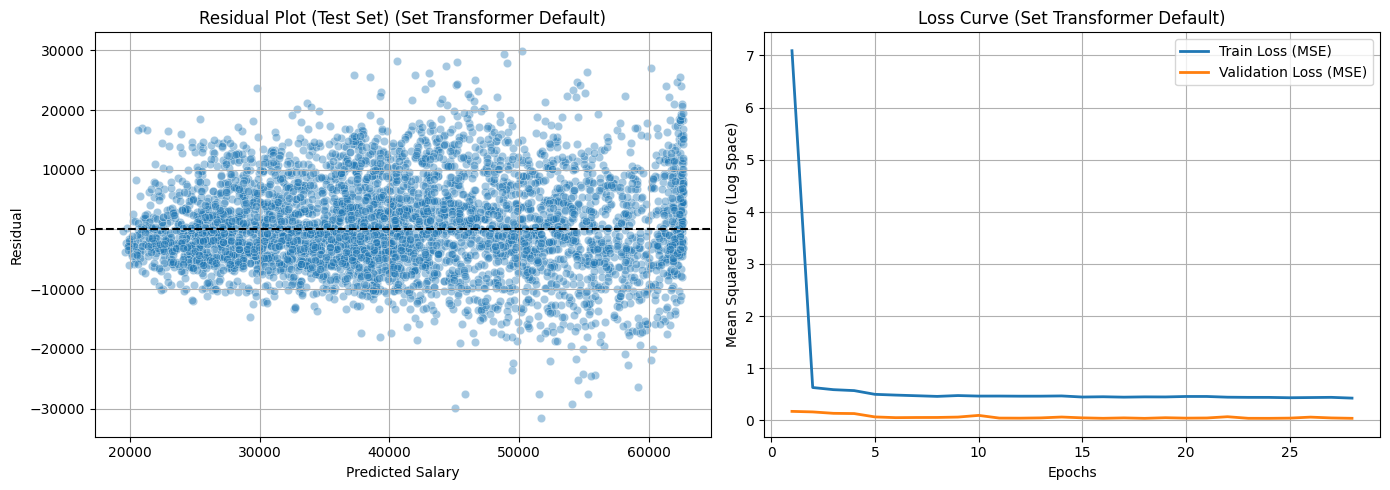

In [ ]:
import random
import warnings
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pickle
import copy
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, learning_curve
import matplotlib.pyplot as plt


warnings.filterwarnings("ignore")

# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# LOAD DATA
df = pd.read_csv("../Unified_Resume_Salary_Dataset.csv")

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"].values

X_train_text = X_text.iloc[train_idx]
X_test_text = X_text.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]
# COUNT VECTOR
vectorizer = CountVectorizer(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*'
)

X_train_count = vectorizer.fit_transform(X_train_text)
X_test_count = vectorizer.transform(X_test_text)


# LOAD ONTOLOGY EMBEDDINGS
emb_path = "../ontology_embeddings.npy"
ontology_embs = torch.tensor(np.load(emb_path)).to(device)

# Compute once from the full dataset, pass it in explicitly
global_max_skills = int(np.diff(
    vectorizer.transform(X_text).tocsr().indptr
).max())
print(f"Global max skills: {global_max_skills}")

def create_set_embeddings(X_count_matrix, embs_tensor, max_skills):  
    X_count_matrix = X_count_matrix.tocsr()
    embs = embs_tensor.cpu().numpy()
    n, d = X_count_matrix.shape[0], embs.shape[1]
    X_set = np.zeros((n, max_skills, d), dtype=np.float32)

    for i in range(n):
        start = X_count_matrix.indptr[i]
        end   = X_count_matrix.indptr[i + 1]
        idx   = X_count_matrix.indices[start:end][:max_skills]  
        if len(idx) > 0:
            X_set[i, :len(idx)] = embs[idx]
    return X_set

# Both use the same max_skills
X_train_set = create_set_embeddings(X_train_count, ontology_embs, global_max_skills)
X_test_set  = create_set_embeddings(X_test_count,  ontology_embs, global_max_skills)


# MODEL
class ISAB(nn.Module):
    def __init__(self, dim, heads, num_inducing=32, dropout=0.1):
        super().__init__()
        self.inducing = nn.Parameter(torch.randn(1, num_inducing, dim))
        self.mha1 = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=dropout)
        self.mha2 = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=dropout)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout)
        )
        self.ln3 = nn.LayerNorm(dim)

    def forward(self, x):
        H, _ = self.mha1(self.inducing.repeat(x.size(0), 1, 1), x, x)
        H = self.ln1(H)
        attn_out, _ = self.mha2(x, H, H)
        out = self.ln2(x + attn_out)
        out = self.ln3(out + self.ffn(out))
        return out


class PMA(nn.Module):
    def __init__(self, dim, heads, dropout=0.1):
        super().__init__()
        self.seed = nn.Parameter(torch.randn(1, 1, dim))
        self.mha = nn.MultiheadAttention(dim, heads, batch_first=True, dropout=dropout)
        self.ln1 = nn.LayerNorm(dim)
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout)
        )
        self.ln2 = nn.LayerNorm(dim)

    def forward(self, x):
        attn_out, _ = self.mha(self.seed.repeat(x.size(0), 1, 1), x, x)
        out = self.ln1(attn_out)               # no residual — correct PMA
        out = self.ln2(out + self.ffn(out))
        return out.mean(dim=1)                 # safe for all batch sizes


class TrueSetTransformer(BaseEstimator, RegressorMixin):
    def __init__(self, input_dim=768, hidden_dim=128, heads=4, num_inducing=32,
                 epochs=50, batch_size=128, lr=1.5e-3, patience=10,
                 dropout=0.1, weight_decay=1e-4):
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.heads = heads
        self.num_inducing = num_inducing
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.dropout = dropout
        self.weight_decay = weight_decay
        self.device = device

    def fit(self, X, y, eval_set=None):
        self.model = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            ISAB(self.hidden_dim, self.heads, self.num_inducing, dropout=self.dropout),
            ISAB(self.hidden_dim, self.heads, self.num_inducing, dropout=self.dropout),
            PMA(self.hidden_dim, self.heads, dropout=self.dropout),
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(self.dropout),
            nn.Linear(64, 1)
        ).to(self.device)

        opt = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        
        loss_fn = nn.MSELoss()

        # 1. FAST GPU LOADING
        X_t = torch.as_tensor(X, dtype=torch.float32, device=self.device)
        y_t = torch.as_tensor(y, dtype=torch.float32, device=self.device).view(-1, 1)

        if eval_set:
            X_val_t = torch.as_tensor(eval_set[0], dtype=torch.float32, device=self.device)
            y_val_t = torch.as_tensor(eval_set[1], dtype=torch.float32, device=self.device).view(-1, 1)

        best_loss = float("inf")
        best_state = copy.deepcopy(self.model.state_dict())
        patience_counter = 0
        n_samples = X_t.size(0)
        self.history = {"train_loss": [], "val_loss": []}
        
        for epoch in range(self.epochs):
            self.model.train()
            
            # 2. FAST NATIVE GPU BATCHING
            perm = torch.randperm(n_samples, device=self.device)
            epoch_train_loss = 0.0
            
            for i in range(0, n_samples, self.batch_size):
                idx = perm[i:i+self.batch_size]
                xb, yb = X_t[idx], y_t[idx]
                
                opt.zero_grad()
                pred = self.model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()
                
                epoch_train_loss += loss.item() * xb.size(0)
                
            epoch_train_loss /= n_samples   

                
            if eval_set:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    # Chunked eval to prevent VRAM spikes
                    for i in range(0, X_val_t.size(0), self.batch_size):
                        xb_v = X_val_t[i:i+self.batch_size]
                        yb_v = y_val_t[i:i+self.batch_size]
                        val_loss += loss_fn(self.model(xb_v), yb_v).item() * xb_v.size(0)
                current_loss = val_loss / X_val_t.size(0)
            else:
                current_loss = epoch_train_loss  


            self.history["train_loss"].append(epoch_train_loss)
            if eval_set:
                self.history["val_loss"].append(current_loss)
                
            # EARLY STOPPING LOGIC
            if current_loss < best_loss:
                best_loss = current_loss
                best_state = copy.deepcopy(self.model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= self.patience:
                print(f"Early stopped at epoch {epoch+1}")  
                break

        # Load best weights
        self.model.load_state_dict(best_state)
        
        # OOM PREVENTION: Flush Tensors
        del X_t, y_t
        if eval_set:
            del X_val_t, y_val_t
        torch.cuda.empty_cache()

        return self

    def predict(self, X):
        self.model.eval()
        X_t = torch.as_tensor(X, dtype=torch.float32, device=self.device)
        preds = []
        
        with torch.no_grad():
            for i in range(0, X_t.size(0), self.batch_size):
                xb = X_t[i:i+self.batch_size]
                preds.append(self.model(xb).cpu().numpy())
                
        # OOM PREVENTION
        del X_t
        torch.cuda.empty_cache()
        
        return np.vstack(preds).flatten()


# 5-FOLD CV
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

train_r2_scores, val_r2_scores = [], []
train_rmse_scores, val_rmse_scores = [], []
train_mae_scores, val_mae_scores = [], []

# Store per-fold (IMPORTANT)
fold_train_r2, fold_val_r2 = [], []
fold_train_rmse, fold_val_rmse = [], []
fold_train_mae, fold_val_mae = [], []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_train_set)):

    X_tr, X_va = X_train_set[tr_idx], X_train_set[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    model = TrueSetTransformer(input_dim=X_train_set.shape[2])
    model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

    tr_pred = model.predict(X_tr)
    va_pred = model.predict(X_va)

    # Compute metrics
    tr_r2 = r2_score(y_tr, tr_pred)
    va_r2 = r2_score(y_va, va_pred)

    tr_rmse = np.sqrt(mean_squared_error(y_tr, tr_pred))
    va_rmse = np.sqrt(mean_squared_error(y_va, va_pred))

    tr_mae = mean_absolute_error(y_tr, tr_pred)
    va_mae = mean_absolute_error(y_va, va_pred)

    # Store for averages
    train_r2_scores.append(tr_r2)
    val_r2_scores.append(va_r2)

    train_rmse_scores.append(tr_rmse)
    val_rmse_scores.append(va_rmse)

    train_mae_scores.append(tr_mae)
    val_mae_scores.append(va_mae)

    # Store per-fold table
    fold_train_r2.append(tr_r2)
    fold_val_r2.append(va_r2)

    fold_train_rmse.append(tr_rmse)
    fold_val_rmse.append(va_rmse)

    fold_train_mae.append(tr_mae)
    fold_val_mae.append(va_mae)

# PER-FOLD RESULTS TABLE
fold_df = pd.DataFrame({
    "Fold": np.arange(1, kf.get_n_splits() + 1),

    "Train_R2": fold_train_r2,
    "Val_R2": fold_val_r2,

    "Train_RMSE": fold_train_rmse,
    "Val_RMSE": fold_val_rmse,

    "Train_MAE": fold_train_mae,
    "Val_MAE": fold_val_mae
})

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)


# METRICS (LOG SCALE - CV ONLY)
cv_train_r2 = np.mean(train_r2_scores)
cv_val_r2   = np.mean(val_r2_scores)

cv_train_rmse = np.mean(train_rmse_scores)
cv_val_rmse   = np.mean(val_rmse_scores)

cv_train_mae = np.mean(train_mae_scores)
cv_val_mae   = np.mean(val_mae_scores)

gap = cv_train_r2 - cv_val_r2

# PRINT PER MODEL SUMMARY
print("\n" + "="*70)
print(f"{'SET TRANSFORMER (DEFAULT) - 5-FOLD CV (LOG SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)

# TRAIN FINAL MODEL ON FULL TRAIN SET
final_model = TrueSetTransformer(input_dim=X_train_set.shape[2])

# Split a small validation portion just for early stopping
X_final_tr, X_final_val, y_final_tr, y_final_val = train_test_split(
    X_train_set, y_train, test_size=0.1, random_state=seed
)

final_model.fit(X_final_tr, y_final_tr, eval_set=(X_final_val, y_final_val))

# Predictions (LOG SCALE)
train_pred_log = final_model.predict(X_train_set)
test_pred_log  = final_model.predict(X_test_set)

# INVERSE TRANSFORM (BACK TO ORIGINAL SALARY)
train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

# METRICS (ORIGINAL SCALE)
train_r2_orig = r2_score(y_train_actual, train_pred)
test_r2_orig  = r2_score(y_test_actual, test_pred)

train_rmse_orig = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse_orig  = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_orig = mean_absolute_error(y_train_actual, train_pred)
test_mae_orig  = mean_absolute_error(y_test_actual, test_pred)

# PRINT
print("\n" + "="*70)
print(f"{'SET TRANSFORMER (DEFAULT) - TRAIN & TEST (ORIGINAL SCALE)':^40}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_orig:>15.4f}{test_r2_orig:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_orig:>15,.2f}{test_rmse_orig:>15,.2f}")
print(f"{'MAE':<10}{train_mae_orig:>15,.2f}{test_mae_orig:>15,.2f}")
print("="*70)




# PLOTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuals = y_test_actual - test_pred

sns.scatterplot(
    x=test_pred,
    y=residuals,
    alpha=0.4,
    ax=axes[0]
)

axes[0].axhline(0, linestyle='--', color='black')
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (Set Transformer Default)")
axes[0].set_xlabel("Predicted Salary")
axes[0].set_ylabel("Residual")



# PLOT EPOCH LOSS CURVE
epochs_run = len(final_model.history["train_loss"])
x_axis = range(1, epochs_run + 1)

axes[1].plot(x_axis, final_model.history["train_loss"], label="Train Loss (MSE)", linewidth=2)
axes[1].plot(x_axis, final_model.history["val_loss"], label="Validation Loss (MSE)", linewidth=2)
axes[1].set_title("Loss Curve (Set Transformer Default)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Mean Squared Error (Log Space)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Hyperparameter-tuned Set Transformer (Simpiflied Version)

Global max skills: 93


[I 2026-05-13 07:19:28,186] A new study created in memory with name: no-name-50f3a747-77d6-4590-9dc7-2073dd8c8d19
[I 2026-05-13 07:26:39,410] Trial 0 finished with value: 0.7581366034090516 and parameters: {'heads': 8, 'hidden_base': 32, 'lr': 0.0016111802442355819}. Best is trial 0 with value: 0.7581366034090516.
[I 2026-05-13 07:49:40,329] Trial 1 finished with value: 0.7609629413734567 and parameters: {'heads': 8, 'hidden_base': 56, 'lr': 0.001051218223724795}. Best is trial 1 with value: 0.7609629413734567.
[I 2026-05-13 07:56:10,798] Trial 2 finished with value: 0.7587010426080347 and parameters: {'heads': 4, 'hidden_base': 48, 'lr': 0.0009799548781307028}. Best is trial 1 with value: 0.7609629413734567.
[I 2026-05-13 07:59:40,111] Trial 3 finished with value: 0.7462733277355401 and parameters: {'heads': 4, 'hidden_base': 32, 'lr': 0.000904447178226524}. Best is trial 1 with value: 0.7609629413734567.
[I 2026-05-13 08:07:14,697] Trial 4 finished with value: 0.7537797158605404 and 


 BEST OPTUNA PARAMETERS
heads: 8
hidden_base: 40
lr: 0.0012867442839482194

=== PER FOLD RESULTS TABLE ===
   Fold  Train_R2    Val_R2  Train_RMSE  Val_RMSE  Train_MAE   Val_MAE
0     1  0.806358  0.794520    0.158549  0.164643   0.119825  0.125037
1     2  0.848078  0.801907    0.140610  0.160834   0.104637  0.118166
2     3  0.749582  0.747094    0.180142  0.183278   0.139726  0.141032
3     4  0.812104  0.763153    0.157372  0.171349   0.118623  0.127971
4     5  0.821004  0.802186    0.152452  0.161483   0.113891  0.120170

           SET TRANSFORMER (TUNED) - 5-FOLD CV (LOG SCALE)            
Metric              Train     Validation            Gap
----------------------------------------------------------------------
R²                 0.8074         0.7818         0.0257
RMSE               0.1578         0.1683               
MAE                0.1193         0.1265               

       SET TRANSFORMER (TUNED) - TRAIN & TEST (ORIGINAL SCALE)        
Metric              Train  

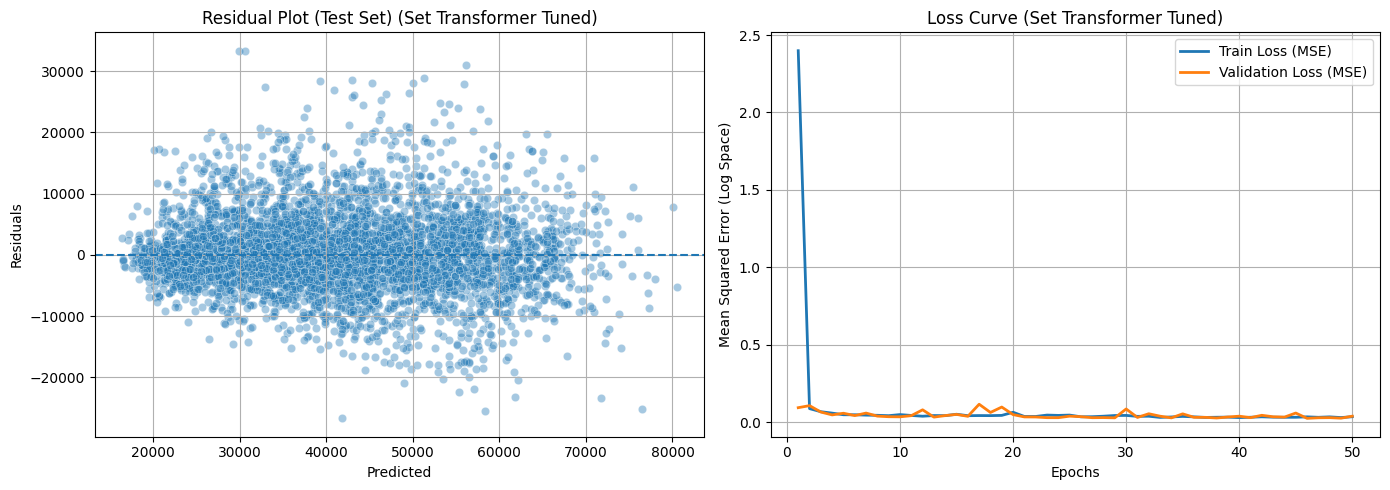

In [ ]:
import random
import warnings
import copy
import gc
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import pickle
import optuna
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import learning_curve
from sklearn.feature_extraction.text import CountVectorizer


warnings.filterwarnings("ignore")

# REPRODUCIBILITY
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# RELOAD DATA (SAFE START)
df = pd.read_csv("../Unified_Resume_Salary_Dataset.csv")

with open("../master_vocab.pkl", "rb") as f:
    master_vocab = pickle.load(f)

train_idx = np.load("../train_idx.npy")
test_idx  = np.load("../test_idx.npy")

X_text = df["Aligned_Text"]
y = df["Log_Salary"].values

X_train_text = X_text.iloc[train_idx]
X_test_text = X_text.iloc[test_idx]
y_train = y[train_idx]
y_test = y[test_idx]


vectorizer = CountVectorizer(
    vocabulary=master_vocab,
    ngram_range=(1, 3),
    token_pattern=r'(?u)\.?[a-z0-9][a-z0-9\+\#\.]*'
)

X_train_count = vectorizer.fit_transform(X_train_text)
X_test_count = vectorizer.transform(X_test_text)

# LOAD ONTOLOGY EMBEDDINGS
emb_path = "../ontology_embeddings.npy"
ontology_embs = torch.tensor(np.load(emb_path)).to(device)

global_max_skills = int(np.diff(
    vectorizer.transform(X_text).tocsr().indptr
).max())
print(f"Global max skills: {global_max_skills}")

def create_set_embeddings(X_count_matrix, embs_tensor, max_skills):  
    X_count_matrix = X_count_matrix.tocsr()
    embs = embs_tensor.cpu().numpy()
    n, d = X_count_matrix.shape[0], embs.shape[1]
    X_set = np.zeros((n, max_skills, d), dtype=np.float32)

    for i in range(n):
        start = X_count_matrix.indptr[i]
        end   = X_count_matrix.indptr[i + 1]
        idx   = X_count_matrix.indices[start:end][:max_skills] 
        if len(idx) > 0:
            X_set[i, :len(idx)] = embs[idx]
    return X_set

# Both use the same max_skills
X_train_set = create_set_embeddings(X_train_count, ontology_embs, global_max_skills)
X_test_set  = create_set_embeddings(X_test_count,  ontology_embs, global_max_skills)


# MODEL
class ISAB(nn.Module):
    def __init__(self, dim, heads, num_inducing=32):
        super().__init__()
        self.inducing = nn.Parameter(torch.randn(1, num_inducing, dim))
        self.mha1 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.mha2 = nn.MultiheadAttention(dim, heads, batch_first=True)
        self.ln1 = nn.LayerNorm(dim)
        self.ln2 = nn.LayerNorm(dim)

    def forward(self, x):
        H, _ = self.mha1(self.inducing.repeat(x.size(0),1,1), x, x)
        H = self.ln1(H)
        out, _ = self.mha2(x, H, H)
        out = self.ln2(out)
        return x + out


class PMA(nn.Module):
    def __init__(self, dim, heads):
        super().__init__()
        self.seed = nn.Parameter(torch.randn(1, 1, dim))
        self.mha = nn.MultiheadAttention(dim, heads, batch_first=True)

    def forward(self, x):
        out, _ = self.mha(self.seed.repeat(x.size(0),1,1), x, x)
        return out.mean(dim=1)


class TrueSetTransformer(BaseEstimator, RegressorMixin):
    def __init__(self, input_dim=768, hidden_dim=128, heads=4, num_inducing=32,
                 epochs=50, batch_size=128, lr=1.5e-3, patience=10):
        
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.heads = heads
        self.num_inducing = num_inducing
        self.epochs = epochs
        self.batch_size = batch_size
        self.lr = lr
        self.patience = patience
        self.device = device

    def fit(self, X, y, eval_set=None):
        self.model = nn.Sequential(
            nn.Linear(self.input_dim, self.hidden_dim),
            ISAB(self.hidden_dim, self.heads, num_inducing=self.num_inducing),
            ISAB(self.hidden_dim, self.heads, num_inducing=self.num_inducing),
            PMA(self.hidden_dim, self.heads),
            nn.Linear(self.hidden_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        ).to(self.device)

        opt = torch.optim.AdamW(self.model.parameters(), lr=self.lr)
        loss_fn = nn.MSELoss()

        # 1. FAST GPU LOADING
        X_t = torch.as_tensor(X, dtype=torch.float32, device=self.device)
        y_t = torch.as_tensor(y, dtype=torch.float32, device=self.device).view(-1, 1)

        if eval_set:
            X_val_t = torch.as_tensor(eval_set[0], dtype=torch.float32, device=self.device)
            y_val_t = torch.as_tensor(eval_set[1], dtype=torch.float32, device=self.device).view(-1, 1)

        best_loss = float("inf")
        best_state = copy.deepcopy(self.model.state_dict())
        patience_counter = 0
        n_samples = X_t.size(0)
        self.history = {"train_loss": [], "val_loss": []}

        for epoch in range(self.epochs):
            self.model.train()
            
            # 2. FAST NATIVE GPU BATCHING
            perm = torch.randperm(n_samples, device=self.device)
            epoch_train_loss = 0.0
            
            for i in range(0, n_samples, self.batch_size):
                idx = perm[i:i+self.batch_size]
                xb, yb = X_t[idx], y_t[idx]
                
                opt.zero_grad()
                pred = self.model(xb)
                loss = loss_fn(pred, yb)
                loss.backward()
                opt.step()
                
                epoch_train_loss += loss.item() * xb.size(0)
                
            epoch_train_loss /= n_samples   

                
            if eval_set:
                self.model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    # Chunked eval to prevent VRAM spikes
                    for i in range(0, X_val_t.size(0), self.batch_size):
                        xb_v = X_val_t[i:i+self.batch_size]
                        yb_v = y_val_t[i:i+self.batch_size]
                        val_loss += loss_fn(self.model(xb_v), yb_v).item() * xb_v.size(0)
                current_loss = val_loss / X_val_t.size(0)
            else:
                current_loss = epoch_train_loss  

            self.history["train_loss"].append(epoch_train_loss)
            if eval_set:
                self.history["val_loss"].append(current_loss)
                
            # EARLY STOPPING LOGIC
            if current_loss < best_loss:
                best_loss = current_loss
                best_state = copy.deepcopy(self.model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= self.patience: 
                break

        # Load best weights
        self.model.load_state_dict(best_state)
        
        # OOM PREVENTION: Flush Tensors
        del X_t, y_t
        if eval_set:
            del X_val_t, y_val_t
        torch.cuda.empty_cache()

        return self

    def predict(self, X):
        self.model.eval()
        X_t = torch.as_tensor(X, dtype=torch.float32, device=self.device)
        preds = []
        
        with torch.no_grad():
            for i in range(0, X_t.size(0), self.batch_size):
                xb = X_t[i:i+self.batch_size]
                preds.append(self.model(xb).cpu().numpy())
                
        # OOM PREVENTION
        del X_t
        torch.cuda.empty_cache()
        
        return np.vstack(preds).flatten()


# OPTUNA OBJECTIVE 
def objective(trial):
    heads = trial.suggest_categorical("heads", [4, 8])
    hidden_base = trial.suggest_int("hidden_base", 32, 64, step=8)
    hidden_dim = hidden_base * heads
    lr = trial.suggest_float("lr", 8e-4, 1.8e-3, log=True)

    kf = KFold(n_splits=3, shuffle=True, random_state=seed)
    train_r2_scores, val_r2_scores, val_rmse_scores = [], [], []

    for tr_idx, val_idx in kf.split(X_train_set):
        X_tr, X_val = X_train_set[tr_idx], X_train_set[val_idx]
        y_tr, y_val = y_train[tr_idx], y_train[val_idx]

        model = TrueSetTransformer(
            input_dim=X_train_set.shape[2],
            hidden_dim=hidden_dim,
            heads=heads,
            num_inducing=32,  # Default setting
            lr=lr,
            epochs=50,        # Default setting
            patience=10,      # Default setting
            batch_size=128    # Default setting
        )
        model.fit(X_tr, y_tr, eval_set=(X_val, y_val))

        train_r2_scores.append(r2_score(y_tr, model.predict(X_tr)))
        val_r2_scores.append(r2_score(y_val, model.predict(X_val)))
        val_rmse_scores.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))

    trial.set_user_attr("train_r2", np.mean(train_r2_scores))
    trial.set_user_attr("val_rmse", np.mean(val_rmse_scores))

    del model
    torch.cuda.empty_cache()
    gc.collect()

    return np.mean(val_r2_scores)



study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

best_params = study.best_params

print("\n" + "="*80)
print(" BEST OPTUNA PARAMETERS")
print("="*80)
for k, v in best_params.items():
    print(f"{k}: {v}")
print("="*80)


# 5-FOLD CV (FINAL MODEL)
kf = KFold(n_splits=5, shuffle=True, random_state=seed)

train_r2_scores, val_r2_scores = [], []
train_rmse_scores, val_rmse_scores = [], []
train_mae_scores, val_mae_scores = [], []
fold_results = []

for tr_idx, va_idx in kf.split(X_train_set):

    X_tr, X_va = X_train_set[tr_idx], X_train_set[va_idx]
    y_tr, y_va = y_train[tr_idx], y_train[va_idx]

    hidden_dim = best_params["hidden_base"] * best_params["heads"]

    model = TrueSetTransformer(
        input_dim=X_train_set.shape[2],
        hidden_dim=hidden_dim,
        heads=best_params["heads"],
        num_inducing=32,      # Default setting
        lr=best_params["lr"],
        epochs=50,            # Default setting
        patience=10,          # Default setting
        batch_size=128        # Default setting
    )

    model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

    tr_pred = model.predict(X_tr)
    va_pred = model.predict(X_va)

    train_r2_scores.append(r2_score(y_tr, tr_pred))
    val_r2_scores.append(r2_score(y_va, va_pred))

    train_rmse_scores.append(np.sqrt(mean_squared_error(y_tr, tr_pred)))
    val_rmse_scores.append(np.sqrt(mean_squared_error(y_va, va_pred)))

    train_mae_scores.append(mean_absolute_error(y_tr, tr_pred))
    val_mae_scores.append(mean_absolute_error(y_va, va_pred))

    fold_results.append({
        "Fold": len(fold_results) + 1,
        "Train_R2": train_r2_scores[-1],
        "Val_R2": val_r2_scores[-1],
        "Train_RMSE": train_rmse_scores[-1],
        "Val_RMSE": val_rmse_scores[-1],
        "Train_MAE": train_mae_scores[-1],
        "Val_MAE": val_mae_scores[-1]
    })


fold_df = pd.DataFrame(fold_results)

print("\n=== PER FOLD RESULTS TABLE ===")
print(fold_df)

cv_train_r2 = np.mean(train_r2_scores)
cv_val_r2   = np.mean(val_r2_scores)

cv_train_rmse = np.mean(train_rmse_scores)
cv_val_rmse   = np.mean(val_rmse_scores)

cv_train_mae = np.mean(train_mae_scores)
cv_val_mae   = np.mean(val_mae_scores)

gap = cv_train_r2 - cv_val_r2


print("\n" + "="*70)
print(f"{'SET TRANSFORMER (TUNED) - 5-FOLD CV (LOG SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Validation':>15}{'Gap':>15}")
print("-"*70)
print(f"{'R²':<10}{cv_train_r2:>15.4f}{cv_val_r2:>15.4f}{gap:>15.4f}")
print(f"{'RMSE':<10}{cv_train_rmse:>15.4f}{cv_val_rmse:>15.4f}{'':>15}")
print(f"{'MAE':<10}{cv_train_mae:>15.4f}{cv_val_mae:>15.4f}{'':>15}")
print("="*70)


# FINAL TRAIN (BEST MODEL)
X_final_tr, X_final_val, y_final_tr, y_final_val = train_test_split(
    X_train_set, y_train, test_size=0.1, random_state=seed
)

hidden = best_params["hidden_base"] * best_params["heads"]

final_model = TrueSetTransformer(
    input_dim=X_train_set.shape[2],
    hidden_dim=hidden_dim,                     
    heads=best_params["heads"],
    num_inducing=32,      # Default setting
    lr=best_params["lr"],
    epochs=50,            # Default setting           
    patience=10,          # Default setting
    batch_size=128        # Default setting
)

final_model.fit(X_final_tr, y_final_tr, eval_set=(X_final_val, y_final_val))


# TRAIN + TEST EVALUATION (ORIGINAL SCALE)
train_pred_log = final_model.predict(X_train_set)
test_pred_log  = final_model.predict(X_test_set)

train_pred = np.expm1(train_pred_log)
test_pred  = np.expm1(test_pred_log)

y_train_actual = np.expm1(y_train)
y_test_actual  = np.expm1(y_test)

train_r2_real = r2_score(y_train_actual, train_pred)
test_r2       = r2_score(y_test_actual, test_pred)

train_rmse_real = np.sqrt(mean_squared_error(y_train_actual, train_pred))
test_rmse       = np.sqrt(mean_squared_error(y_test_actual, test_pred))

train_mae_real = mean_absolute_error(y_train_actual, train_pred)
test_mae       = mean_absolute_error(y_test_actual, test_pred)


print("\n" + "="*70)
print(f"{'SET TRANSFORMER (TUNED) - TRAIN & TEST (ORIGINAL SCALE)':^70}")
print("="*70)
print(f"{'Metric':<10}{'Train':>15}{'Test':>15}")
print("-"*70)
print(f"{'R²':<10}{train_r2_real:>15.4f}{test_r2:>15.4f}")
print(f"{'RMSE':<10}{train_rmse_real:>15,.2f}{test_rmse:>15,.2f}")
print(f"{'MAE':<10}{train_mae_real:>15,.2f}{test_mae:>15,.2f}")
print("="*70)


# RESIDUAL PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Residual Plot ---
residuals = y_test_actual - test_pred
sns.scatterplot(x=test_pred, y=residuals, ax=axes[0], alpha=0.4)
axes[0].axhline(0, linestyle="--")
axes[0].grid(True)
axes[0].set_title("Residual Plot (Test Set) (Set Transformer Tuned)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residuals")


# PLOT EPOCH LOSS CURVE
epochs_run = len(final_model.history["train_loss"])
x_axis = range(1, epochs_run + 1)

axes[1].plot(x_axis, final_model.history["train_loss"], label="Train Loss (MSE)", linewidth=2)
axes[1].plot(x_axis, final_model.history["val_loss"],   label="Validation Loss (MSE)", linewidth=2)
axes[1].set_title("Loss Curve (Set Transformer Tuned)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Mean Squared Error (Log Space)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()